:::{admonition} Do this exercise yourself!
:class: important

This notebook is an exercise for practicing using plenoptic. You should work through it on your own, either by clicking on one of the following buttons or opening up a new notebook on your own machine and following along.

Regardless of which you choose, you should keep this page open for reference, as the links to other pages in the documentation (and some images) are broken in the downloaded and binder notebooks.

If you would like to install everything required to run this notebooks on your local machine, run `pip install plenoptic[nb]`. See [](install-doc) and [](jupyter-doc) for more details.

Download the executed notebook: **{nb-download}`1_simple_metamer.ipynb`**!

Run it in your browser: **{binder}`1_simple_metamer.ipynb`**!

:::

(simple-metamer)=
# Minimal metamer synthesis example

See [](metamer-nb) page for more details about using the {class}`~plenoptic.Metamer` object.

In [1]:
# needed for the plotting/animating:
import matplotlib.pyplot as plt
import torch

import plenoptic as po

plt.rcParams["animation.html"] = "html5"
# use single-threaded ffmpeg for animation writer
plt.rcParams["animation.writer"] = "ffmpeg"
plt.rcParams["animation.ffmpeg_args"] = ["-threads", "1"]
# so that relative sizes of axes created by po.plot.imshow and others look right
plt.rcParams["figure.dpi"] = 72
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

The following code block:
- initializes an image and a model
- runs metamer synthesis until convergence

In [2]:
img = po.data.einstein().to(DEVICE)
model = po.models.LuminanceGainControl(
    kernel_size=(31, 31), pad_mode="circular", pretrained=True, cache_filt=True
)
model.to(DEVICE)
po.remove_grad(model)
model.eval()
met = po.Metamer(img, model)
met.synthesize(max_iter=1300, stop_criterion=1e-11, store_progress=10)

  0%|          | 0/1300 [00:00<?, ?it/s]

Next, we need to ensure that the metamer synthesis succeeded. In the previous example we worked through, I had ensured that we ran the synthesis for long enough that we didn't need to check this, but in general, you do.

There are many possible visualizations one can make. We have a helper function that should help get you started. It shows the metamer, the synthesis loss over time, and (if possible) the representation error.

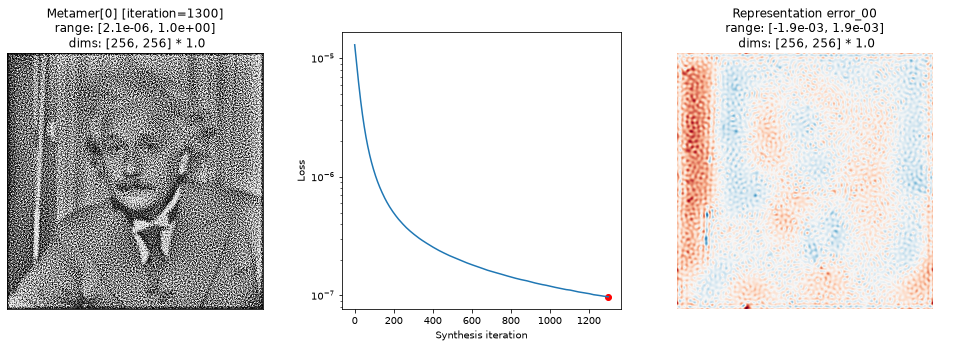

In [3]:
fig = po.plot.synthesis_status(met)

In the above figure, we can see that the loss has decreased to a low value and, importantly, that it looks like it has stabilized.

The representation error is easier to understand if we view it over time, which we can do with the following helper function:

In [4]:
po.plot.synthesis_animate(met)

We can see that the representation error decreases relatively uniformly across the image.

(simple-metamer-diff-target)=
## Different target image

Try using a different target image than the one of Einstein above and running metamer synthesis until completion:

:::{admonition} Loading other images
:class: hint

Try one of the other {ref}`included images <images-api>` or use {func}`plenoptic.load_images` to load one from disk.

:::

In [ ]:
img = ...  # WRITE SOMETHING NEW HERE
img = img.to(DEVICE)
met = po.Metamer(img, model)
met.synthesize(max_iter=1300, stop_criterion=1e-11, store_progress=10)
po.plot.synthesis_status(met);

And maybe animate to see what synthesis looks like?

In [ ]:
po.plot.synthesis_animate(met)

(simple-metamer-diff-initial)=
## Different initial image

While we often initialize from a patch of white noise, it can be interesting to start from a different image as well. Using one of the same tools as above for loading another image, initialize metamer synthesis from another starting point and run it to completion:

In [ ]:
met = po.Metamer(img, model)
met.setup(initial_image=...)  # FINISH THE CALL TO setup
met.synthesize(max_iter=1300, stop_criterion=1e-11, store_progress=10)
po.plot.synthesis_status(met);

And maybe animate to see what synthesis looks like?

In [ ]:
po.plot.synthesis_animate(met)

## Other models

Try any of the above with a different model! Try one of the other {ref}`LGN-inspired models <models-api>`.

If you want a more complex model, see the [](3_textures) or [](4_torchvision) exercises.